In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import PowerTransformer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix


from sklearn import metrics 
from sklearn.model_selection import  train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

# Read the Data


In [2]:
#Loading the Data

df = pd.read_csv('J:\Project\ineuron\Live_sensor\Aps_failure_data.csv', na_values='na')
aps_data = df.copy()
aps_data.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,pos,153204,0.0,182.0,NaN,0.0,0.0,0.0,0.0,0.0,...,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0
1,pos,453236,NaN,2926.0,NaN,0.0,0.0,0.0,0.0,222.0,...,7908038.0,3026002.0,5025350.0,2025766.0,1160638.0,533834.0,493800.0,6914.0,0.0,0.0
2,pos,72504,NaN,1594.0,1052.0,0.0,0.0,0.0,244.0,178226.0,...,1432098.0,372252.0,527514.0,358274.0,332818.0,284178.0,3742.0,0.0,0.0,0.0
3,pos,762958,NaN,NaN,NaN,NaN,NaN,776.0,281128.0,2186308.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pos,695994,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,1397742.0,495544.0,361646.0,28610.0,5130.0,212.0,0.0,0.0,NaN,NaN


In [3]:
#Checking the rows and columns of the data

aps_data.shape

(36188, 171)

In [4]:
# "Class" is the target variable so checking the unique values if it 

aps_data['class'].value_counts()

class
neg    35188
pos     1000
Name: count, dtype: int64

From above we can infere that their is a serious class imbalance in the Data

In [5]:
# Defining the Numerical and Categorical Columns

num_cols = [feature for feature in aps_data.columns if aps_data[feature].dtype != 'O']
cat_cols = [feature for feature in aps_data.columns if aps_data[feature].dtype == 'O']

print(f"Total Number of Numeric Columns: {len(num_cols)}, List of Columns {num_cols}")
print(f"Total Number of Categorical Columns: {len(cat_cols)}, List of Columns {cat_cols}")

Total Number of Numeric Columns: 170, List of Columns ['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000

As the Data which we have is a sensor data Interpretation of the data is not required

Moving forward to handling Missing Values

Text(0, 0.5, 'Percentage of Missing Values')

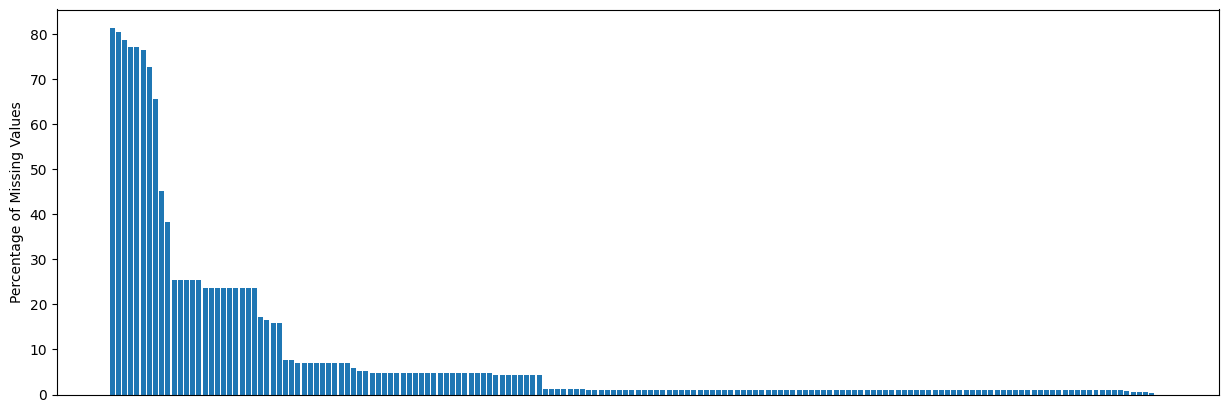

In [6]:
#Plotting Missing values count for each column
fig, ax = plt.subplots(figsize=(15,5))

missing  = aps_data.isna().sum().div(aps_data.shape[0]).mul(100).to_frame().sort_values(by=0, ascending=False)

ax.bar(missing.index, missing.values.T[0])
plt.xticks([])
plt.ylabel('Percentage of Missing Values')

In [7]:
# Droping the Columns which have more the 70% missing values

drop_cols = missing[missing[0] > 70]
aps_data.drop(list(drop_cols.index), axis=1, inplace=True)
print(aps_data.shape)

(36188, 164)


In [8]:
# This are the dropped columns which had more tha 70% of missing values
drop_cols

,0
br_000,81.410965
bq_000,80.501824
bp_000,78.794075
cr_000,77.086327
ab_000,77.086327
bo_000,76.533658
bn_000,72.761689


In [9]:
# Calculating the Total Percentage of missing values after droping the columns

missing_values_count = aps_data.isnull().sum().sum()
total_cells = np.prod(aps_data.shape)

print(f"Total percentage of Missing Values: {((missing_values_count/total_cells)*100):.2f}%")

Total percentage of Missing Values: 5.37%


Visualization of values in Target Variable

Positive Class: 1000, Negative Class: 35188


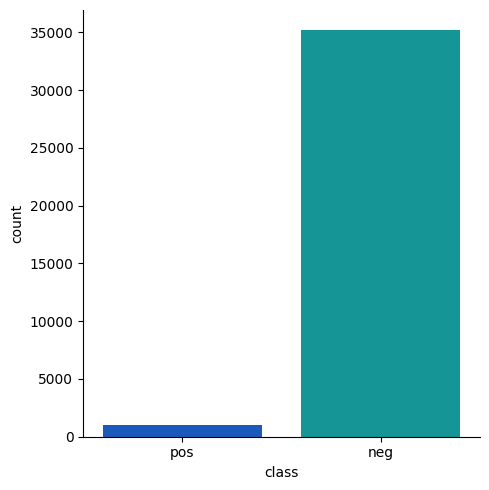

In [10]:
print(f"Positive Class: {aps_data['class'].value_counts()[1]}, Negative Class: {aps_data['class'].value_counts()[0]}")

#Count Plot of Target Variable 
sns.catplot(data=aps_data, x='class', kind='count', palette='winter', alpha=1)

In [11]:
# Creating Function for Model Evaluation

def evaluate_clf(true, predicted):
    '''
    This Function take true values and predicted values
    Returns: Accuracy, F1-score, Precision, Recall, ROC-AUC score
    
    '''
    
    acc = accuracy_score(true, predicted)
    f1_ = f1_score(true, predicted) 
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    roc_auc = roc_auc_score(true, predicted)
    return acc,f1_,precision,recall,roc_auc
    

In [12]:
# Create the cost of the Model as per the description

def total_cost(y_true, y_pred):
    '''
    This function takes true values and predicted values and prints the Total Cost for missclassification
    
    '''
    tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()
    cost=10*fp + 500*fn
    return cost

In [13]:
# Creating a function which will return Evaluation report of models

def evaluate_models(X, y, models):
    '''
    This function takes X, y and model dictionary
    It splits the data into Train data and Test data
    Iterated through all the models
    Return: DataFrame which contains all the report with cost
    
    '''
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  
    
    cost_list = []
    models_list = []
    accuracy_list = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train)   # Model training
        
        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.prect(X_test)
        
        #Train performance
        train_acc,train_f1,train_precision,train_recall,train_roc_auc = evaluate_clf(y_train, y_train_pred)
        train_cost = total_cost(y_train, y_train_pred)
        
        #Test Performance
        test_acc,test_f1,test_precision,test_recall,test_roc_auc = evaluate_clf(y_test,y_test_pred)
        test_cost = total_cost(y_test, y_test_pred)
        
        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])
        
        print(f'Model performance on Train Data')
        print(f'- Accuracy: {train_acc:.2f}')
        print(f'- F1 Score: {train_f1:.2f}')
        print(f'- Precision: {train_precision:.2f}')
        print(f'- Recall: {train_recall:.2f}')
        print(f'- ROC AUC score: {train_roc_auc:.2f}')
        print(f'- COST: {train_cost}')
        
        print('-----------------------------------------------------')
        
        print(f'Model performance on Test Data')
        print(f'- Accuracy: {test_acc:.2f}')
        print(f'- F1 Score: {test_f1:.2f}')
        print(f'- Precision: {test_precision:.2f}')
        print(f'- Recall: {test_recall:.2f}')
        print(f'- ROC AUC score: {test_roc_auc:.2f}')
        print(f'- COST: {test_cost}')
        
        cost_list.append(test_cost)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, cost_list)), columns=['Model Name', 'Cost']).sort_values(by=['Cost'])
    
    return report        

Plotting the distribution of all the Numeric Data 

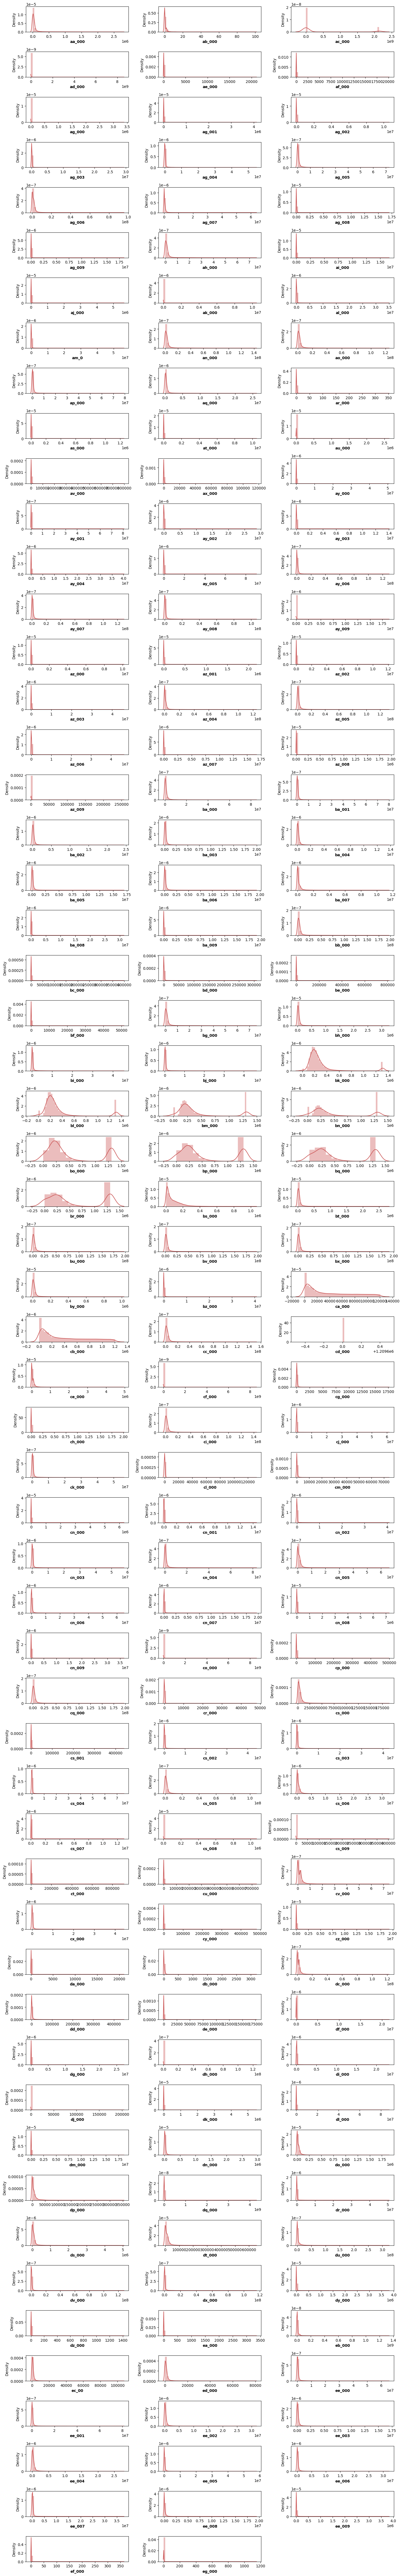

In [17]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

plt.figure(figsize=(15, 100))
for i, col in enumerate(numeric_features):
    plt.subplot(60, 3, i+1)
    sns.distplot(x=df[col], color='indianred')
    plt.xlabel(col, weight='bold')
    plt.tight_layout()

In [18]:
# Splitting the Independent and Dependent variables

X = aps_data.drop('class', axis=1)
y = aps_data['class']

# Manualy encoding the dependent variable
y = y.replace({'pos':1, 'neg':0})

# Experiment 1: KNN imputer for Null Values

In [21]:
rs = RobustScaler()
X1 = rs.fit_transform(X)

results = []

# Defining imputer 
imp = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')
strategies = [str(i) for i in [1,3,5,7,9]]
for s in strategies:
    pipeline = Pipeline(steps=[
        ('i', KNNImputer(n_neighbors=int(s))),
        ('m', LogisticRegression())
    ])
    scores=cross_val_score(pipeline, X1, y, scoring='accuracy', cv=2, n_jobs=-1)
    results.append(scores)
    print(f'n_neighbors: {s}, Accuracy: {mean(scores):.2f}')
    

n_neighbors: 1, Accuracy: 0.71
n_neighbors: 3, Accuracy: 0.72
n_neighbors: 5, Accuracy: 0.72
n_neighbors: 7, Accuracy: 0.71
n_neighbors: 9, Accuracy: 0.69


In [ ]:
num_features = X.select_dtypes(exclude='object').columns

knn_pipeline=Pipeline(steps=[
    ('imputer': KNNimputer(n_neighbors=)),
    ('scaler', RobustScaler())
])

X_knn = knn_pipeline.fit_transform(X)

In [ ]:
from imblearn.combine import SMOTETomek

